In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

def find_root(current_path, marker="setup.py"):
    current_path = Path(current_path).resolve()
    for parent in [current_path] + list(current_path.parents):
        if (parent / marker).exists():
            return parent
    return current_path

PROJECT_ROOT = find_root(Path.cwd())
DATASETS_DIR = PROJECT_ROOT / "data" / "datasets_clean" / "generalization"
RESULTS_DIR = PROJECT_ROOT / "data" / "results_clean" / "generalization" / "mountainCar"
ASSETS_DIR = PROJECT_ROOT / "experiments" / "shared" / "assets"
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

print(f"Project root found at: {PROJECT_ROOT}")

import math
import itertools
import imageio
import random
import re

import numpy as np
import pandas as pd
import torch
import seaborn as sns
import matplotlib.pyplot as plt
import gymnasium as gym

from tqdm import tqdm
from matplotlib.colors import ListedColormap, BoundaryNorm

from rl_methods.q_learning import run_q_learning

from rl_methods.mdp_clean import (
    StateDiscretizer,
    ActionDiscretizer,
    FeaturesMDP,
    TabularFeatureMap,
)

from rl_methods.data_collection_clean import (
    GymDataBuffer,
    DatasetAnalyzer,
)

def set_global_seed(seed):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    if hasattr(torch.backends, "cudnn"):
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


seed = 44
set_global_seed(seed)

DATASET_PATH = DATASETS_DIR / "mountaincar_data.csv"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Project root found at: /shared/home/mauro.diaz/work/FOGAS


Using device: cuda


In [3]:
def evaluate_mean_steps_greedy_and_solver(
    solver_or_policy,
    state_disc,
    action_disc,
    env_id="MountainCar-v0",
    n_seeds=10,
    max_steps=200,
    base_seed=seed,
):
    """
    Evaluates the same learned policy in two ways:

    1. greedy:
       Converts policy probabilities to deterministic argmax actions.

    2. solver:
       Uses the solver policy without greedy conversion.
       For fogas_clean / fqi_clean this means sampling from solver.pi rows.
       For continuous solvers with sample_action(), it calls sample_action(..., deterministic=False).

    Returns mean steps +/- variance over n_seeds rollouts.
    """

    if hasattr(solver_or_policy, "pi"):
        policy = solver_or_policy.pi
        solver = solver_or_policy
    else:
        policy = solver_or_policy
        solver = None

    if hasattr(policy, "detach"):
        policy_np = policy.detach().cpu().numpy()
    else:
        policy_np = np.asarray(policy)

    def rollout(eval_seed, mode):
        env = gym.make(
            env_id,
            max_episode_steps=max_steps,
            goal_velocity=GOAL_VELOCITY,
        )

        rng = np.random.default_rng(eval_seed)
        obs, _ = env.reset(seed=eval_seed)

        done = False
        steps = 0

        while not done:
            if mode == "solver" and solver is not None and hasattr(solver, "sample_action"):
                action_id = int(solver.sample_action(obs, deterministic=False))
            else:
                state_id = state_disc.obs_to_state_id(obs)

                if mode == "greedy":
                    action_id = int(np.argmax(policy_np[state_id]))
                elif mode == "solver":
                    probs = np.asarray(policy_np[state_id], dtype=np.float64)
                    probs = np.clip(probs, 0.0, None)
                    probs_sum = probs.sum()

                    if not np.isfinite(probs_sum) or probs_sum <= 0.0:
                        probs = np.ones(action_disc.n_actions) / action_disc.n_actions
                    else:
                        probs = probs / probs_sum

                    action_id = int(rng.choice(action_disc.n_actions, p=probs))
                else:
                    raise ValueError(f"Unknown mode: {mode}")

            env_action = action_disc.action_id_to_env_action(action_id)
            obs, reward, terminated, truncated, _ = env.step(env_action)

            steps += 1
            done = terminated or truncated

        env.close()
        return steps

    rows = []

    for mode in ["greedy", "solver"]:
        steps_list = [
            rollout(base_seed + i, mode=mode)
            for i in range(n_seeds)
        ]

        mean_steps = float(np.mean(steps_list))
        var_steps = float(np.var(steps_list, ddof=1)) if n_seeds > 1 else 0.0
        success_count = int(sum(s < max_steps for s in steps_list))

        rows.append({
            "mode": mode,
            "n_seeds": n_seeds,
            "mean_steps": mean_steps,
            "variance_steps": var_steps,
            "mean_plus_minus_variance": f"{mean_steps:.2f} ± {var_steps:.2f}",
            "successes": success_count,
            "steps": steps_list,
        })

    return pd.DataFrame(rows)

# Data Collection

### Setup

In [10]:
ENV_ID = "MountainCar-v0"
GAMMA = 0.9
GOAL_POSITION = 0.5
GOAL_VELOCITY = 0.0
TIME_LIMIT = 200

OBS_LOW = np.array([-1.2, -0.07], dtype=np.float64)
OBS_HIGH = np.array([0.6, 0.07], dtype=np.float64)
STATE_BINS = np.array([30, 30], dtype=np.int64)

ACTION_IDS = np.array([0, 1, 2], dtype=np.int64)
ACTION_LABELS = {0: "left", 1: "coast", 2: "right"}
INITIAL_OBS_REFERENCE = np.array([-0.5, 0.0], dtype=np.float64)

state_disc = StateDiscretizer(
    low=OBS_LOW,
    high=OBS_HIGH,
    bins=STATE_BINS,
    terminal_obs_predicate=lambda obs: obs[0] >= GOAL_POSITION and obs[1] >= GOAL_VELOCITY,
)

action_disc = ActionDiscretizer(ACTION_IDS, ACTION_LABELS)

N_STATES = state_disc.n_states
N_ACTIONS = action_disc.n_actions
GOAL_STATE_ID = state_disc.absorbing_state_id
INITIAL_STATE_ID = state_disc.obs_to_state_id(INITIAL_OBS_REFERENCE)

### Train q-learning policy

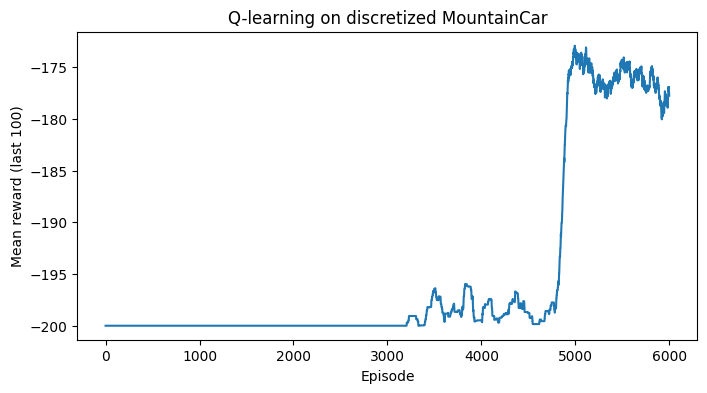

Initial state greedy action: left
Q(initial state): tensor([ -9.9996, -10.0000, -10.0000], dtype=torch.float64)


In [11]:
q_star_ql, _, rewards_ql = run_q_learning(
    episodes=6000,
    alpha=0.9,
    gamma=GAMMA,
    epsilon_start=1.0,
    seed=seed,
    env_id=ENV_ID,
    env_kwargs={"goal_velocity": GOAL_VELOCITY},
    obs_to_state_id=state_disc.obs_to_state_id,
    n_states=N_STATES,
    n_actions=N_ACTIONS,
    terminal_state_id=GOAL_STATE_ID,
    initial_state_id=INITIAL_STATE_ID,
    action_id_to_label=action_disc.action_id_to_label,
    plot=True,
    plot_title="Q-learning on discretized MountainCar",
)

greedy_actions_ql = torch.argmax(q_star_ql, dim=1)

pi_matrix_ql = torch.zeros((N_STATES, N_ACTIONS), dtype=torch.float64)
pi_matrix_ql[torch.arange(N_STATES), greedy_actions_ql] = 1.0
pi_matrix_ql[GOAL_STATE_ID] = 1.0 / N_ACTIONS

### Build reset distribution from learned trajectory

In [12]:
trajectory_state_ids, trajectory_reset_distribution, trajectory_steps = (
    GymDataBuffer.create_distribution(
        policy_matrix=pi_matrix_ql,
        state_disc=state_disc,
        action_disc=action_disc,
        env_id=ENV_ID,
        start_obs=INITIAL_OBS_REFERENCE,
        max_steps=TIME_LIMIT,
        seed=seed,
        goal_velocity=GOAL_VELOCITY,
    )
)

print(f"Trajectory states: {len(trajectory_state_ids)}")
print(f"Trajectory steps: {trajectory_steps}")

Trajectory states: 91
Trajectory steps: 160


### Collect data

In [13]:
df = GymDataBuffer.collect_continuous(
    policy_matrix=pi_matrix_ql,
    state_disc=state_disc,
    action_disc=action_disc,
    env_id=ENV_ID,
    n_transitions=40_000,
    epsilon=0.4,
    proportions=(0.8, 0.2),
    episode_based=True,
    max_steps_per_episode=200,
    reset_probs={"x0": 0.1, "custom": 0.9},
    custom_reset_distribution=trajectory_reset_distribution,
    reset_obs_mode="uniform_in_bin",
    seed=seed,
    save_path=DATASET_PATH,
    verbose=True,
    drop_self_transitions=False,
    start_obs=INITIAL_OBS_REFERENCE,
    goal_velocity=GOAL_VELOCITY,
    wait_for_state_change=False,
)

df.head()

Saved continuous dataset to /home/mauro/Desktop/EMAI/Ljubljana/Thesis/Code/data/datasets_clean/generalization/mountaincar_data.csv


,episode,step,state,action,reward,next_state,done,policy_id,reset_mode,position,velocity,next_position,next_velocity
0,0,1,337,0,1.0,336,False,1,custom,-0.481849,-0.036576,-0.519737,-0.037888
1,0,2,336,0,1.0,306,False,1,custom,-0.519737,-0.037888,-0.558654,-0.038917
2,0,3,306,0,1.0,306,False,1,custom,-0.558654,-0.038917,-0.598309,-0.039655
3,0,4,306,0,1.0,276,False,1,custom,-0.598309,-0.039655,-0.638408,-0.040099
4,0,5,276,1,1.0,246,False,1,custom,-0.638408,-0.040099,-0.677663,-0.039255


### Plotting it

Dataset rows: 40000
Columns: ['episode', 'step', 'state', 'action', 'reward', 'next_state', 'done', 'policy_id', 'reset_mode', 'position', 'velocity', 'next_position', 'next_velocity']

State coverage: 581/900 (64.6%)
Unvisited states: 319
Done transitions: 71

Action counts:
action
0    13014
1    12099
2    14887
Name: count, dtype: int64

Reset mode frequencies:
reset_mode
custom    0.88
x0        0.12
Name: proportion, dtype: float64

Policy frequencies:
policy_id
0    0.71975
1    0.28025
Name: proportion, dtype: float64


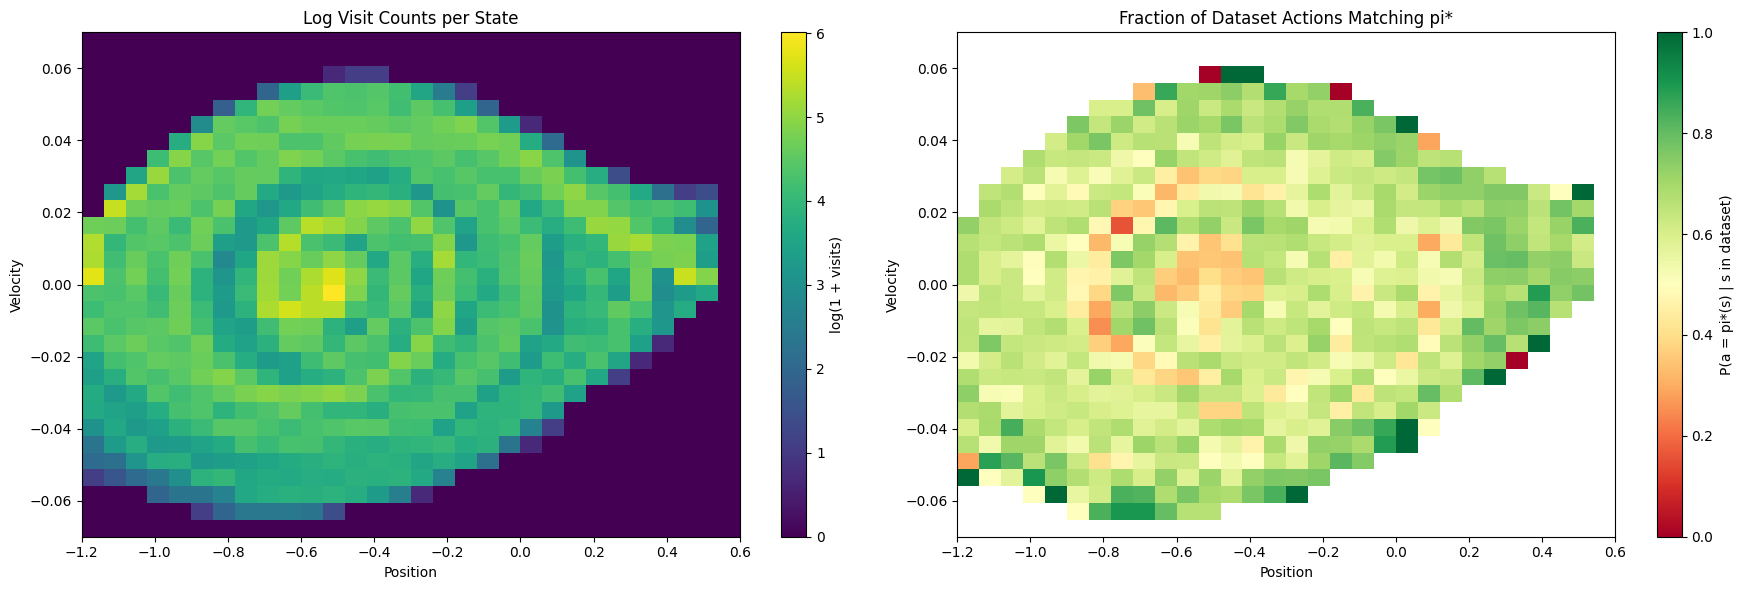

In [15]:
import numpy as np
import torch
import matplotlib.pyplot as plt

CORE_STATE_COUNT = state_disc.core_state_count
STATE_BINS = state_disc.bins
BIN_EDGES = state_disc.bin_edges

visited_states = set(df["state"].unique())
all_states = set(range(CORE_STATE_COUNT))
visited_core_states = visited_states & all_states
unvisited = all_states - visited_core_states

print(f"Dataset rows: {len(df)}")
print(f"Columns: {list(df.columns)}")
print(
    f"\nState coverage: {len(visited_core_states)}/{CORE_STATE_COUNT} "
    f"({100 * len(visited_core_states) / CORE_STATE_COUNT:.1f}%)"
)
print(f"Unvisited states: {len(unvisited)}")
print(f"Done transitions: {df['done'].sum()}")

print("\nAction counts:")
print(df["action"].value_counts().sort_index())

print("\nReset mode frequencies:")
print(df["reset_mode"].value_counts(normalize=True).sort_index())

print("\nPolicy frequencies:")
print(df["policy_id"].value_counts(normalize=True).sort_index())

visit_count_grid = np.zeros(tuple(STATE_BINS), dtype=np.int64)
optimal_match_grid = np.full(tuple(STATE_BINS), fill_value=np.nan)

greedy_actions = torch.argmax(
    torch.as_tensor(pi_matrix_ql, dtype=torch.float64).reshape(
        state_disc.n_states, action_disc.n_actions
    ),
    dim=1,
).cpu().numpy()

state_counts = df["state"].value_counts()
pair_counts = df.groupby(["state", "action"]).size()

for s in all_states:
    i, j = state_disc.state_id_to_multi_bin(s)
    visit_count_grid[i, j] = int(state_counts.get(s, 0))

for s in visited_core_states:
    i, j = state_disc.state_id_to_multi_bin(s)
    total = int(state_counts.get(s, 0))
    on_policy = int(pair_counts.get((s, int(greedy_actions[s])), 0))
    optimal_match_grid[i, j] = on_policy / total if total > 0 else np.nan

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

im0 = axes[0].pcolormesh(
    BIN_EDGES[0],
    BIN_EDGES[1],
    np.log1p(visit_count_grid).T,
    cmap="viridis",
    shading="flat",
)
axes[0].set_title("Log Visit Counts per State")
axes[0].set_xlabel("Position")
axes[0].set_ylabel("Velocity")
fig.colorbar(im0, ax=axes[0], label="log(1 + visits)")

im1 = axes[1].pcolormesh(
    BIN_EDGES[0],
    BIN_EDGES[1],
    optimal_match_grid.T,
    cmap="RdYlGn",
    shading="flat",
    vmin=0,
    vmax=1,
)
axes[1].set_title("Fraction of Dataset Actions Matching pi*")
axes[1].set_xlabel("Position")
axes[1].set_ylabel("Velocity")
fig.colorbar(im1, ax=axes[1], label="P(a = pi*(s) | s in dataset)")

plt.tight_layout()
plt.show()

# Linear Solvers

In [4]:
from rl_methods.fogas_clean import FOGASSolver
from rl_methods.fqi_clean import FQISolver

ENV_ID = "MountainCar-v0"
GAMMA = 0.9
GOAL_POSITION = 0.5
GOAL_VELOCITY = 0.0
MIN_POSITION = -1.2
MAX_POSITION = 0.6
MAX_SPEED = 0.07
TIME_LIMIT = 200

STATE_BINS = np.array([30, 30], dtype=np.int64)
OBS_LOW = np.array([MIN_POSITION, -MAX_SPEED], dtype=np.float64)
OBS_HIGH = np.array([MAX_POSITION, MAX_SPEED], dtype=np.float64)

ACTION_IDS = np.array([0, 1, 2], dtype=np.int64)
ACTION_LABELS = {0: "left", 1: "coast", 2: "right"}

INITIAL_OBS_REFERENCE = np.array([-0.5, 0.0], dtype=np.float64)

state_disc = StateDiscretizer(
    low=OBS_LOW,
    high=OBS_HIGH,
    bins=STATE_BINS,
    terminal_obs_predicate=lambda obs: (
        obs[0] >= GOAL_POSITION and obs[1] >= GOAL_VELOCITY
    ),
)

action_disc = ActionDiscretizer(
    action_values=ACTION_IDS,
    action_labels=ACTION_LABELS,
)

CORE_STATE_COUNT = state_disc.core_state_count
GOAL_STATE_ID = state_disc.absorbing_state_id
N_STATES = state_disc.n_states
N_ACTIONS = action_disc.n_actions

states = torch.arange(N_STATES, dtype=torch.int64)
actions = torch.arange(N_ACTIONS, dtype=torch.int64)

BIN_EDGES = state_disc.bin_edges
BIN_CENTERS = state_disc.bin_centers

INITIAL_STATE_ID = state_disc.obs_to_state_id(INITIAL_OBS_REFERENCE)

print(f"Reference initial abstract state id: {INITIAL_STATE_ID}")
print(f"Non-terminal abstract states: {CORE_STATE_COUNT}")
print(f"Total abstract states: {N_STATES}")
print(f"Discrete action ids: {ACTION_IDS}")
print(f"Action labels: {[action_disc.action_id_to_label(int(a)) for a in ACTION_IDS]}")
print(f"Dataset path: {DATASET_PATH}")

Reference initial abstract state id: 345
Non-terminal abstract states: 900
Total abstract states: 901
Discrete action ids: [0 1 2]
Action labels: ['left', 'coast', 'right']
Dataset path: /shared/home/mauro.diaz/work/FOGAS/data/datasets_clean/generalization/mountaincar_data.csv


## Features

In [5]:
phi_tabular = TabularFeatureMap(
    n_states=state_disc.n_states,
    n_actions=action_disc.n_actions,
)

mdp_tabular = FeaturesMDP(
    states=states,
    actions=actions,
    phi=phi_tabular,
    gamma=GAMMA ** 5,
    x0=INITIAL_STATE_ID,
    omega=None,
)

print(f"Tabular feature dimension d: {mdp_tabular.d}")

Tabular feature dimension d: 2703


In [6]:
RBF_BINS = np.array([15, 15], dtype=np.int64)

RBF_EDGES = [
    np.linspace(lo, hi, n_bins + 1, dtype=np.float64)
    for lo, hi, n_bins in zip(OBS_LOW, OBS_HIGH, RBF_BINS)
]
RBF_GRID_CENTERS = [0.5 * (edges[:-1] + edges[1:]) for edges in RBF_EDGES]
RBF_CENTERS = np.array(list(itertools.product(*RBF_GRID_CENTERS)), dtype=np.float64)

K_CENTERS = len(RBF_CENTERS)

width_position = (MAX_POSITION - MIN_POSITION) / RBF_BINS[0]
width_velocity = (MAX_SPEED - (-MAX_SPEED)) / RBF_BINS[1]

VARIANCE_SCALE = 0.05
SIGMA_SQUARED = np.array(
    [width_position**2, width_velocity**2],
    dtype=np.float64,
) * VARIANCE_SCALE

D_RBF = K_CENTERS * action_disc.n_actions

def phi_rbf(state_id, action_id):
    obs = state_disc.state_id_to_center_obs(state_id)

    if obs is None:
        return torch.zeros(D_RBF, dtype=torch.float64)

    diff_sq = (RBF_CENTERS - obs) ** 2
    f_x = np.exp(-0.5 * np.sum(diff_sq / SIGMA_SQUARED, axis=1))

    feat = np.zeros(D_RBF, dtype=np.float64)
    start_idx = int(action_id) * K_CENTERS
    end_idx = start_idx + K_CENTERS
    feat[start_idx:end_idx] = f_x

    return torch.from_numpy(feat)

mdp_rbf = FeaturesMDP(
    states=states,
    actions=actions,
    phi=phi_rbf,
    gamma=GAMMA ** 5,
    x0=INITIAL_STATE_ID,
    omega=None,
)

print(f"Number of RBF centers k: {K_CENTERS}")
print(f"RBF feature dimension d: {mdp_rbf.d}")

Number of RBF centers k: 225
RBF feature dimension d: 675


### FOGAS tabular

In [7]:
solver_fogas_tabular = FOGASSolver(
    mdp=mdp_tabular,
    phi=mdp_tabular.phi,
    csv_path=DATASET_PATH,
    device=device,
    beta=1e-6,
    seed=seed,
)

solver_fogas_tabular.run(
    alpha=0.0001,
    eta=0.00002,
    rho=0.5,
    tqdm_print=True,
    T=20000,
)

display(evaluate_mean_steps_greedy_and_solver(solver_fogas_tabular, state_disc, action_disc))

[FOGASSolver] omega estimated via regression (beta_omega=1.00e-06, n=40000)


FOGAS:   2%|██▌                                                                                                                  | 437/20000 [00:24<18:21, 17.77it/s]


KeyboardInterrupt: 

### FOGAS RBF

In [8]:
solver_fogas_rbf = FOGASSolver(
    mdp=mdp_rbf,
    phi=mdp_rbf.phi,
    csv_path=DATASET_PATH,
    device=device,
    beta=1e-6,
    seed=seed,
)

solver_fogas_rbf.run(
    alpha=0.0001,
    eta=0.00002,
    rho=0.5,
    tqdm_print=True,
    T=20000,
)

display(evaluate_mean_steps_greedy_and_solver(solver_fogas_rbf, state_disc, action_disc))

[FOGASSolver] omega estimated via regression (beta_omega=1.00e-06, n=40000)


FOGAS: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20000/20000 [04:24<00:00, 75.51it/s]


,mode,n_seeds,mean_steps,variance_steps,mean_plus_minus_variance,successes,steps
0,greedy,10,150.9,315.655556,150.90 ± 315.66,9,"[135, 146, 148, 149, 145, 142, 147, 149, 148, ..."
1,solver,10,200.0,0.000000,200.00 ± 0.00,0,"[200, 200, 200, 200, 200, 200, 200, 200, 200, ..."


### FQI tabular

In [9]:
solver_fqi_tabular = FQISolver(
    mdp=mdp_tabular,
    phi=mdp_tabular.phi,
    csv_path=DATASET_PATH,
    device=device,
    seed=seed,
    ridge=1e-2,
    augment_terminal_transitions=True,
)

solver_fqi_tabular.run(
    K=5000,
    tau=0.1,
    verbose=True,
)

display(evaluate_mean_steps_greedy_and_solver(solver_fqi_tabular, state_disc, action_disc))


FQI: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [01:09<00:00, 72.20it/s, theta_norm=100.0799]


,mode,n_seeds,mean_steps,variance_steps,mean_plus_minus_variance,successes,steps
0,greedy,10,187.8,386.844444,187.80 ± 386.84,3,"[200, 157, 200, 160, 200, 200, 161, 200, 200, ..."
1,solver,10,187.8,386.844444,187.80 ± 386.84,3,"[200, 157, 200, 160, 200, 200, 161, 200, 200, ..."


### FQI RBF

In [10]:
solver_fqi_rbf = FQISolver(
    mdp=mdp_rbf,
    phi=mdp_rbf.phi,
    csv_path=DATASET_PATH,
    device=device,
    seed=seed,
    ridge=1e-2,
    augment_terminal_transitions=True,
)

solver_fqi_rbf.run(
    K=5000,
    tau=0.1,
    verbose=True,
)

display(evaluate_mean_steps_greedy_and_solver(solver_fqi_rbf, state_disc, action_disc))

FQI: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [00:17<00:00, 283.47it/s, theta_norm=179.6453]


,mode,n_seeds,mean_steps,variance_steps,mean_plus_minus_variance,successes,steps
0,greedy,10,195.3,220.9,195.30 ± 220.90,1,"[200, 153, 200, 200, 200, 200, 200, 200, 200, ..."
1,solver,10,195.3,220.9,195.30 ± 220.90,1,"[200, 153, 200, 200, 200, 200, 200, 200, 200, ..."


# Generalized FOGAS